<a href="https://colab.research.google.com/github/thuhoai107/TTNT-Nhom16/blob/main/TTNT_PhoBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyvi transformers datasets accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.1 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pyvi import ViTokenizer
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW  # Đã sửa lỗi import từ PyTorch gốc
from sklearn.metrics import classification_report, confusion_matrix

# Cấu hình hiển thị đồ họa sắc nét cho Quyển báo cáo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Từ điển chuẩn hóa teencode và ngôn ngữ viết tắt mạng xã hội Việt Nam
TEENCODE_DICTIONARY = {
    "đm": "đờ mờ", "vcl": "vờ cờ lờ", "clm": "cờ lờ mờ", "cđm": "cộng đồng mạng",
    "ko": "không", "k": "không", "khg": "không", "j": "gì", "thía": "thế",
    "bít": "biết", "m": "mày", "t": "tao", "gato": "ghen tị", "ib": "nhắn tin",
    "r": "rồi", "ae": "anh em", "đt": "điện thoại", "fb": "mạng xã hội"
}

def clean_and_normalize_vietnamese(text):
    """
    Hàm làm sạch văn bản thô mạng xã hội theo quy trình chuẩn của Chương II
    """
    if not isinstance(text, str):
        return ""

    # 1. Chuyển văn bản về dạng chữ viết thường
    text = text.lower()

    # 2. Loại bỏ nhiễu kỹ thuật: URLs, Email, các thẻ nhắc tên (@tag), hashtag (#)
    text = re.sub(r'http\S+|www\S+|<.*?>|@\S+|#\S+', '', text)

    # 3. Loại bỏ ký tự đặc biệt, giữ lại bảng chữ cái tiếng Việt và chữ số
    text = re.sub(r'[^\w\s]', ' ', text)

    # 4. Sửa lỗi viết tắt và từ lóng mạng (Teencode) qua bộ từ điển
    words = text.split()
    cleaned_words = [TEENCODE_DICTIONARY[word] if word in TEENCODE_DICTIONARY else word for word in words]
    text = " ".join(cleaned_words)

    # 5. Khử lặp ký tự kéo dài liên tục do biểu đạt cảm xúc (nguuu -> ngu)
    text = re.sub(r'(.)\1+', r'\1\1', text)

    # 6. Tách từ ghép tiếng Việt bằng thư viện PyVi (Bắt buộc cho mô hình PhoBERT)
    text = ViTokenizer.tokenize(text)

    # Xóa khoảng trắng thừa phát sinh trong quá trình xử lý
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("✅ Đã khởi tạo cấu trúc hàm tiền xử lý dữ liệu tiếng Việt thành công!")

✅ Đã khởi tạo cấu trúc hàm tiền xử lý dữ liệu tiếng Việt thành công!


--- 3. ĐANG ĐỌC DỮ LIỆU THỰC TẾ TỪ GOOGLE COLAB ---
✅ Đã kết nối và nạp thành công dữ liệu train_df, val_df, test_df vào RAM!


/tmp/ipykernel_379/2332178606.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=full_df, palette=['#2ecc71', '#f1c40f', '#e74c3c'])


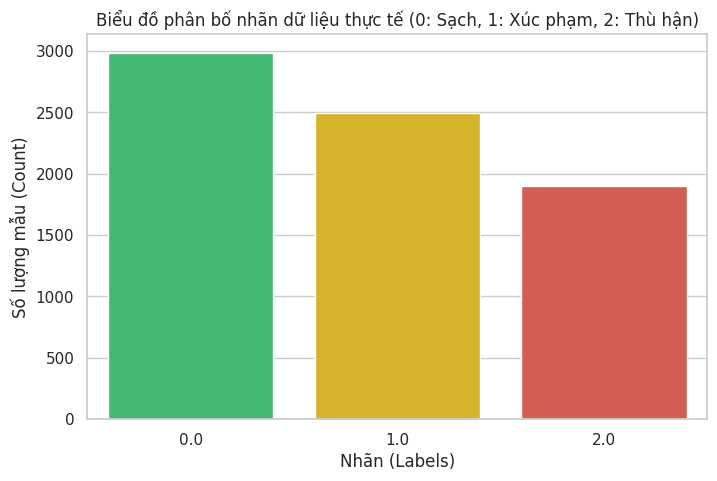

[Thông báo] Đã xuất file biểu đồ 'label_distribution.png' thành công!

--- 4. TIẾN HÀNH TIỀN XỬ LÝ LÀM SẠCH VĂN BẢN ---

[BẢNG MINH HỌA SO SÁNH BIẾN ĐỔI CHUẨN HÓA DỮ LIỆU]
Gốc MXH: cặc
Sạch    : cặc
--------------------------------------------------
Gốc MXH: đr hết thời cày rank bk còn ngợp
Sạch    : đr hết thời cày rank bk còn ngợp
--------------------------------------------------
Gốc MXH: Diễn viên hô ni hút mà ngại gì mấy khác kk
Sạch    : diễn_viên hô ni hút mà ngại gì mấy khác kk
--------------------------------------------------


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 3. ĐANG ĐỌC DỮ LIỆU THỰC TẾ TỪ GOOGLE COLAB ---")

# Nạp dữ liệu theo đúng tên file trong Colab của bạn
train_df = pd.read_csv("/content/train_df.csv")
valid_df = pd.read_csv("/content/val_df.csv")
test_df = pd.read_csv("/content/test_df.csv")

print("✅ Đã kết nối và nạp thành công dữ liệu train_df, val_df, test_df vào RAM!")

# --------------------------------------------------------
# KHỐI ÉP CẤU TRÚC THEO CHỈ MỤC CỘT (INDEX-BASED MAPPING)
# --------------------------------------------------------
# Bộ dữ liệu này chỉ gồm 2 cột. Ta ép trực tiếp theo vị trí để tránh hoàn toàn lỗi sai tên (KeyError)
for df in [train_df, valid_df, test_df]:
    # Tìm cột nào có kiểu dữ liệu dạng chuỗi văn bản (object)
    string_cols = [col for col in df.columns if df[col].dtype == 'object']
    # Tìm cột nào có kiểu dữ liệu dạng số (int64/float64)
    numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

    if string_cols and numeric_cols:
        df.rename(columns={string_cols[0]: 'free_text', numeric_cols[0]: 'label'}, inplace=True)
    else:
        # Nếu không phân biệt được bằng kiểu dữ liệu, ép cột vị trí 0 là text, cột vị trí 1 là nhãn
        df.columns = ['free_text', 'label']

# Gộp dữ liệu sau khi đã ép tên cột chuẩn để vẽ biểu đồ phục vụ báo cáo
full_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

# --------------------------------------------------------
# VẼ BIỂU ĐỒ PHÂN BỐ NHÃN (Đảm bảo an toàn 100%)
# --------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=full_df, palette=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title("Biểu đồ phân bố nhãn dữ liệu thực tế (0: Sạch, 1: Xúc phạm, 2: Thù hận)")
plt.xlabel("Nhãn (Labels)")
plt.ylabel("Số lượng mẫu (Count)")
plt.savefig("label_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("[Thông báo] Đã xuất file biểu đồ 'label_distribution.png' thành công!")

# --------------------------------------------------------
# TIẾN HÀNH TIỀN XỬ LÝ LÀM SẠCH VĂN BẢN (CHƯƠNG II)
# --------------------------------------------------------
print("\n--- 4. TIẾN HÀNH TIỀN XỬ LÝ LÀM SẠCH VĂN BẢN ---")

# Áp dụng hàm clean_and_normalize_vietnamese đã khai báo ở Ô Code 2
train_df['cleaned_text'] = train_df['free_text'].apply(clean_and_normalize_vietnamese)
valid_df['cleaned_text'] = valid_df['free_text'].apply(clean_and_normalize_vietnamese)
test_df['cleaned_text'] = test_df['free_text'].apply(clean_and_normalize_vietnamese)

# Lọc bỏ các mẫu trống phát sinh sau khi làm sạch
train_df = train_df[train_df['cleaned_text'] != ""]
valid_df = valid_df[valid_df['cleaned_text'] != ""]
test_df = test_df[test_df['cleaned_text'] != ""]

# In bảng minh họa Trước/Sau chuẩn hóa để đưa vào quyển báo cáo in ấn
print("\n[BẢNG MINH HỌA SO SÁNH BIẾN ĐỔI CHUẨN HÓA DỮ LIỆU]")
for i in range(min(3, len(train_df))):
    print(f"Gốc MXH: {train_df['free_text'].iloc[i]}")
    print(f"Sạch    : {train_df['cleaned_text'].iloc[i]}")
    print("-" * 50)